In [ ]:
%matplotlib inline

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ovrlpy
import polars as pl
import tifffile
from matplotlib_scalebar.scalebar import ScaleBar

In [ ]:
import sys

import matplotlib

sys.path.append("../..")

from ovrlpy._plotting import _plot_signal_integrity

from utils import CM, FONT, save_kwargs

matplotlib.rc("font", **FONT)

In [4]:
data_path = Path(
    "/dh-projects/ag-ishaque/raw_data/vizgen-merfish/vz-receptor-showcase/Slice2/Replicate1"
)

coordinate_path = "../detected_transcripts.parquet"
image_path = data_path / "images"

In [5]:
transformation_mtx = np.loadtxt(image_path / "micron_to_mosaic_pixel_transform.csv")
transformation_mtx

array([[   9.20788193,    0.        , -377.22518921],
       [   0.        ,    9.20783615,  939.3838501 ],
       [   0.        ,    0.        ,    1.        ]])

In [6]:
transcripts = ovrlpy.io.read_MERSCOPE(coordinate_path).filter(
    pl.col("x") >= 0, pl.col("y") >= 0
)

In [7]:
brain = ovrlpy.Ovrlp(transcripts, n_components=30, n_workers=16, random_state=42)

brain.process_coordinates(gridsize=1, shift=False)
brain.fit_transcripts(min_transcripts=20)
brain.compute_VSI()

determining pseudocells
found 49999 pseudocells
sampling expression:


100%|██████████| 48/48 [00:48<00:00,  1.01s/it]


Modeling 30 pseudo-celltype clusters;


100%|██████████| 300/300 [06:29<00:00,  1.30s/it]


In [8]:
import pickle

with open("brain_noshift.pickle", "wb") as file:
    pickle.dump(brain, file)

In [9]:
import pickle

with open("brain_noshift.pickle", "rb") as file:
    brain = pickle.load(file)

In [52]:
doublets = brain.detect_doublets(min_signal=3, integrity_sigma=2)

In [53]:
def finalize_axes(ax, x, y, window_size):
    ax.set_aspect("equal")
    ax.set(xticks=[], yticks=[])
    if x is not np.nan:
        ax.set_xlim(x - window_size, x + window_size)
    if y is not np.nan:
        ax.set_ylim(y - window_size, y + window_size)


def plot_doublet(ovrlp, imgs, x, y, window_size=50, figsize=None):
    signal_integrity = ovrlp.integrity_map[
        int(y) - window_size : int(y) + window_size,
        int(x) - window_size : int(x) + window_size,
    ]

    signal_strength = ovrlp.signal_map[
        int(y) - window_size : int(y) + window_size,
        int(x) - window_size : int(x) + window_size,
    ]

    roi_transcripts = ovrlp.subset_transcripts(x, y, window_size=window_size).sort("z")
    _, embedding_color = ovrlp.transform_transcripts(roi_transcripts)
    roi_transcripts = roi_transcripts.with_columns(RGB=embedding_color)

    return plot_transcripts(
        imgs,
        roi_transcripts,
        signal_integrity,
        signal_strength,
        x,
        y,
        window_size,
        figsize=figsize,
    )


def plot_transcripts(
    imgs,
    roi_transcripts,
    signal_integrity,
    signal_strength,
    x,
    y,
    window_size,
    *,
    threshold=2,
    figsize=None,
):
    fig, axs = plt.subplots(ncols=10, figsize=figsize)

    scatter_kwargs = dict(s=1, lw=0, rasterized=True)

    ax_top = axs[0]
    roi_top = roi_transcripts.filter(pl.col("z") > pl.col("z_center"))
    ax_top.scatter(x=roi_top["x"], y=roi_top["y"], c=roi_top["RGB"], **scatter_kwargs)
    finalize_axes(ax_top, x, y, window_size)
    ax_top.set_title("top")

    ax_bottom = axs[1]
    roi_bottom = roi_transcripts.filter(pl.col("z") < pl.col("z_center")).reverse()
    ax_bottom.scatter(
        x=roi_bottom["x"], y=roi_bottom["y"], c=roi_bottom["RGB"], **scatter_kwargs
    )
    finalize_axes(ax_bottom, x, y, window_size)
    ax_bottom.set_title("bottom")

    ax_integrity = axs[2]
    _plot_signal_integrity(ax_integrity, signal_integrity, signal_strength, threshold)
    finalize_axes(ax_integrity, window_size, window_size, window_size)
    ax_integrity.set_title("VSI")
    ax_integrity.set_facecolor("black")

    for (name, im), ax in zip(imgs.items(), axs[3:]):
        ax.imshow(im[get_range(x, y, window_size)], origin="lower")
        ax.set(xticks=[], yticks=[], title=name)

    return fig

In [54]:
def get_range(x, y, r, transform=transformation_mtx):
    def _range(low, hi):
        return slice(round(low), round(hi))

    lower = transform @ np.array([x - r, y - r, 1])
    upper = transform @ np.array([x + r, y + r, 1])

    colrange = _range(lower[0], upper[0])
    rowrange = _range(lower[1], upper[1])

    return rowrange, colrange

## DAPI

In [55]:
dapi_files = {int(p.stem.split("_z")[1]): p for p in image_path.glob("mosaic_DAPI*")}

In [56]:
tifs = {z: tifffile.TiffReader(dapi_files[z]) for z in sorted(dapi_files.keys())}

In [57]:
for tag in tifs[0].pages[0].tags:
    print(tag.name, tag.value)

ImageWidth 89085
ImageLength 69628
BitsPerSample 16
Compression 1
PhotometricInterpretation 1
ImageDescription {"ImageJ": "1.47a\n", "images": 1, "channels": 1, "slices": 1, "frames": 1, "hyperstack": true, "loop": false, "shape": [69628, 89085]}
StripOffsets (528,)
SamplesPerPixel 1
RowsPerStrip 69628
StripByteCounts (12405620760,)
XResolution (1, 1)
YResolution (1, 1)
ResolutionUnit 1
Software tifffile.py


In [58]:
images = {z: tif.pages[0].asarray(out="memmap") for z, tif in tifs.items()}

In [59]:
doublet_idxs = [1, 2, 8, 9]

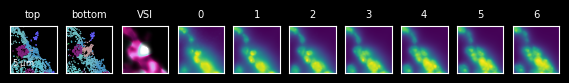

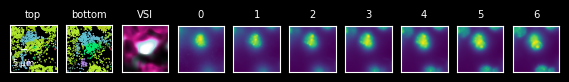

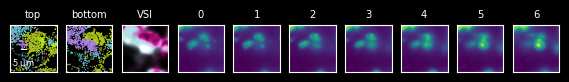

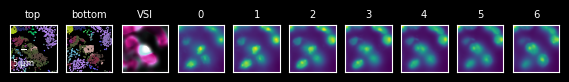

In [60]:
with plt.style.context("dark_background"):
    for i in doublet_idxs:
        x, y = doublets["x", "y"].row(i)
        fig = plot_doublet(
            brain, images, x, y, window_size=20, figsize=(18 * CM, 3 * CM)
        )
        fig.axes[0].add_artist(
            ScaleBar(
                1,
                units="um",
                length_fraction=0.2,
                loc="lower left",
                frameon=False,
                color="w",
            )
        )

        fig.savefig(f"doublet_dapi{i + 1}.svg", **save_kwargs)

In [61]:
# cleanup
del images

for tif in tifs.values():
    tif.close()

del tifs

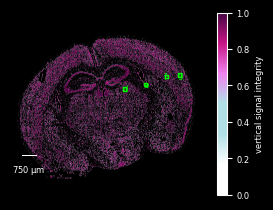

In [62]:
alphabet = "abcdefghijklmnopqrstuvwxyz"

fig = ovrlpy.plot_signal_integrity(
    brain,
    histogram=False,
    scalebar=dict(
        dx=1,
        units="um",
        frameon=False,
        color="w",
        loc="lower left",
        length_fraction=0.1,
    ),
    figsize=(8 * CM, 6 * CM),
)

ax = fig.axes[0]

ax.set_axis_off()

for i in range(len(doublet_idxs)):
    x, y = doublets["x", "y"].row(i)

    ax.text(x + 100, y, alphabet[i + 3], color="lime", fontsize=6, va="center")
    ax.scatter(x, y, marker="s", s=5, edgecolors="lime", facecolors="None", lw=1)


ax.invert_yaxis()
ax.invert_xaxis()

fig.savefig("signal_integrity_rectangles.svg", **save_kwargs)

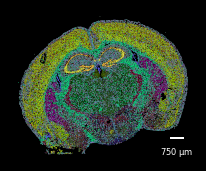

In [63]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=1, lw=0)

    fig, ax = plt.subplots(figsize=(9 * CM, 5 * CM))
    _ = ovrlpy.plot_tissue(
        brain,
        ax=ax,
        scalebar=dict(
            dx=1,
            units="um",
            frameon=False,
            color="w",
            loc="lower right",
            length_fraction=0.1,
        ),
        **scatter_kwargs,
    )
    ax.set_axis_off()
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.collections[0].set_rasterized(True)
    fig.savefig("localmaxima.svg", **save_kwargs)

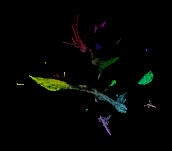

In [64]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=1, lw=0)

    fig, ax = plt.subplots(figsize=(5 * CM, 5 * CM))
    _ = ovrlpy.plot_umap(brain, ax=ax, scatter_kwargs=scatter_kwargs)
    ax.set_axis_off()
    ax.collections[0].set_rasterized(True)

    for t in fig.axes[0].texts:
        t.set(color="white")

    fig.savefig("umap.svg", **save_kwargs)